# Hydroclimatic Time Series Analysis

In [2]:
!pip install download

In [1]:
import numpy as np

In [2]:
import pandas as pd

In [3]:
import matplotlib.pyplot as plt

In [4]:
from download import download

In [5]:
#path = download ('file link','file path')

In [6]:
dataset = pd.read_csv(r"D:\\NITD\\2nd Sem\\Computational Simulation Lab\\rainfall.csv")

In [7]:
dataset

,Month,Rainfall
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121
...,...,...
139,1960-08,606
140,1960-09,508
141,1960-10,461
142,1960-11,390


In [8]:
dataset['Month'] = pd.to_datetime(dataset['Month'])

In [9]:
dataset

,Month,Rainfall
0,1949-01-01,112
1,1949-02-01,118
2,1949-03-01,132
3,1949-04-01,129
4,1949-05-01,121
...,...,...
139,1960-08-01,606
140,1960-09-01,508
141,1960-10-01,461
142,1960-11-01,390


In [10]:
indexed_dataset = dataset.set_index(['Month'])
indexed_dataset

,Rainfall
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
...,...
1960-08-01,606
1960-09-01,508
1960-10-01,461


In [11]:
indexed_dataset.tail()

,Rainfall
Month,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


In [12]:
indexed_dataset.head()

,Rainfall
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


In [13]:
indexed_dataset.head(10)

,Rainfall
Month,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121
1949-06-01,135
1949-07-01,148
1949-08-01,148
1949-09-01,136


In [14]:
plt.rcParams['figure.figsize'] = (12,4)
plt.rcParams['axes.grid'] = True
plt.rcParams['font.size'] = 14

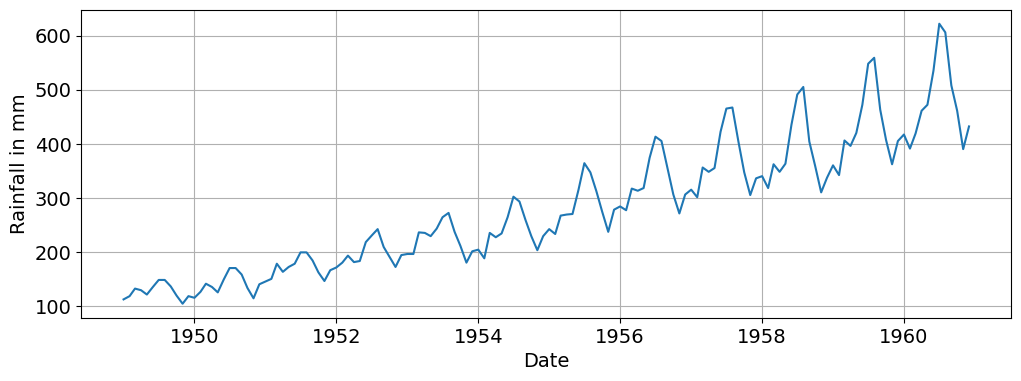

In [15]:
plt.xlabel('Date')
plt.ylabel('Rainfall in mm')
plt.plot(indexed_dataset)
plt.show()

In [16]:
rollmean = indexed_dataset.rolling(window = 12).mean()
rollstd = indexed_dataset.rolling(window = 12).std()
print(rollmean,rollstd)

              Rainfall
Month                 
1949-01-01         NaN
1949-02-01         NaN
1949-03-01         NaN
1949-04-01         NaN
1949-05-01         NaN
...                ...
1960-08-01  463.333333
1960-09-01  467.083333
1960-10-01  471.583333
1960-11-01  473.916667
1960-12-01  476.166667

[144 rows x 1 columns]              Rainfall
Month                
1949-01-01        NaN
1949-02-01        NaN
1949-03-01        NaN
1949-04-01        NaN
1949-05-01        NaN
...               ...
1960-08-01  83.630500
1960-09-01  84.617276
1960-10-01  82.541954
1960-11-01  79.502382
1960-12-01  77.737125

[144 rows x 1 columns]


## Checking Stationarity of a Timeseries

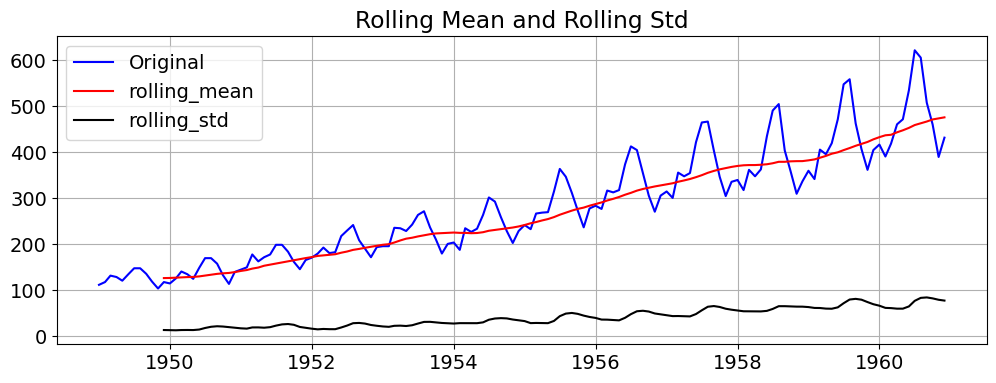

In [17]:
original = plt.plot(indexed_dataset, color = 'blue', label = 'Original')
mean = plt.plot(rollmean, color = 'red', label = 'rolling_mean')
std = plt.plot(rollstd, color = 'black', label = 'rolling_std')
plt.legend(loc = 'best')
plt.title('Rolling Mean and Rolling Std')
plt.show()

In [18]:
def test_stationarity(timeseries):
    # Determining rolling statistics
    rollmean = timeseries.rolling(window = 12).mean()
    rollstd = timeseries.rolling(window = 12).std()
    #Plotting graphs
    original = plt.plot(timeseries, color = 'blue', label = 'Original')
    mean = plt.plot(rollmean, color = 'red', label = 'rolling_mean')
    std = plt.plot(rollstd, color = 'black', label = 'rolling_std')
    plt.legend(loc = 'best')
    plt.title('Rolling Mean and Rolling Std')
    plt.show()

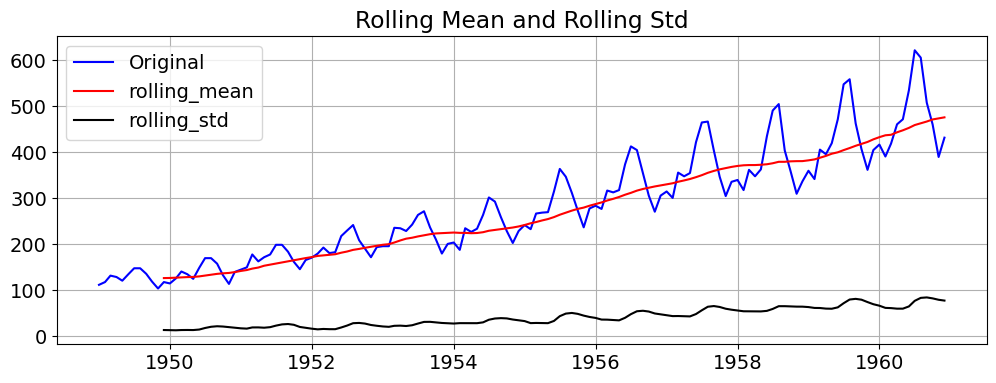

In [19]:
test_stationarity(indexed_dataset)

### Converting non-stationary data to stationary

In [20]:
indexed_dataset_logscale = np.log(indexed_dataset)

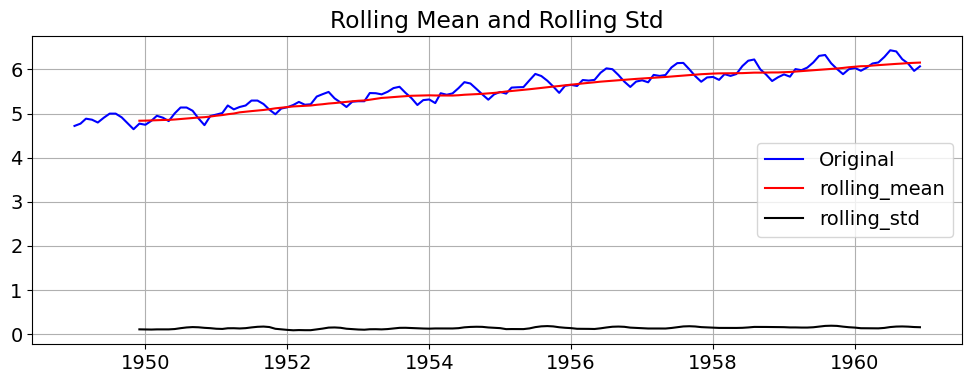

In [21]:
test_stationarity(indexed_dataset_logscale)

In [22]:
moving_average = indexed_dataset_logscale.rolling(window = 12).mean()
dataset_logscale_minus_ma = indexed_dataset_logscale - moving_average
dataset_logscale_minus_ma

,Rainfall
Month,
1949-01-01,NaN
1949-02-01,NaN
1949-03-01,NaN
1949-04-01,NaN
1949-05-01,NaN
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


In [23]:
#Removing NaN values
dataset_revised = dataset_logscale_minus_ma.dropna()
dataset_revised

,Rainfall
Month,
1949-12-01,-0.065494
1950-01-01,-0.093449
1950-02-01,-0.007566
1950-03-01,0.099416
1950-04-01,0.052142
...,...
1960-08-01,0.282363
1960-09-01,0.098235
1960-10-01,-0.009230


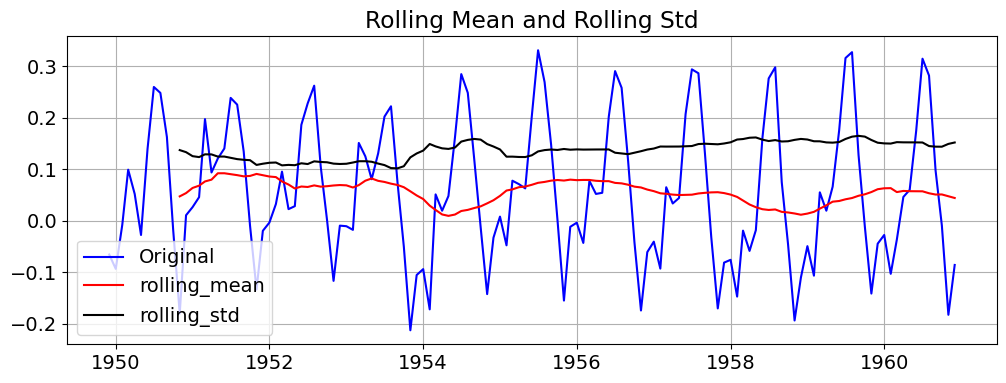

In [24]:
test_stationarity(dataset_revised)

### Differencing with the previous value

In [25]:
datasetlogshifting = indexed_dataset_logscale - indexed_dataset_logscale.shift()

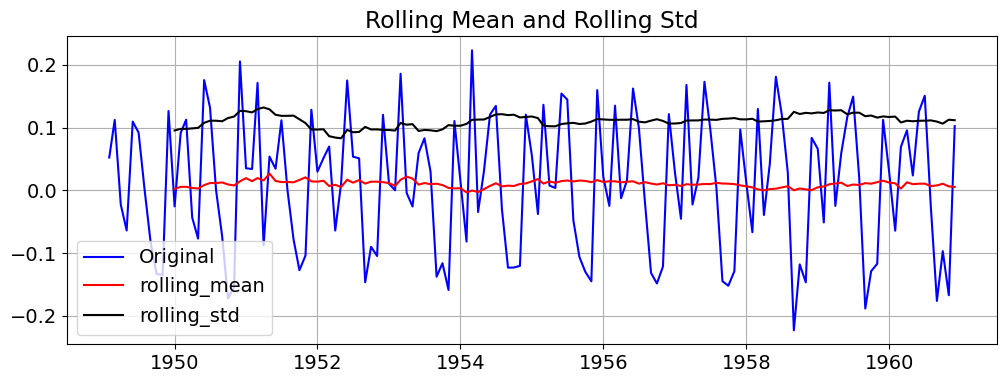

In [26]:
test_stationarity(datasetlogshifting)

In [29]:
indexed_dataset_logscale

,Rainfall
Month,
1949-01-01,4.718499
1949-02-01,4.770685
1949-03-01,4.882802
1949-04-01,4.859812
1949-05-01,4.795791
...,...
1960-08-01,6.406880
1960-09-01,6.230481
1960-10-01,6.133398


In [30]:
datasetlogshifting

,Rainfall
Month,
1949-01-01,NaN
1949-02-01,0.052186
1949-03-01,0.112117
1949-04-01,-0.022990
1949-05-01,-0.064022
...,...
1960-08-01,-0.026060
1960-09-01,-0.176399
1960-10-01,-0.097083


### Seasonal Decomposition

In [27]:
import statsmodels

ModuleNotFoundError: No module named 'statsmodels'

In [32]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [33]:
decomposition = seasonal_decompose(indexed_dataset_logscale)

In [34]:
trend = decomposition.trend

In [35]:
seasonal = decomposition.seasonal

In [36]:
residual = decomposition.resid

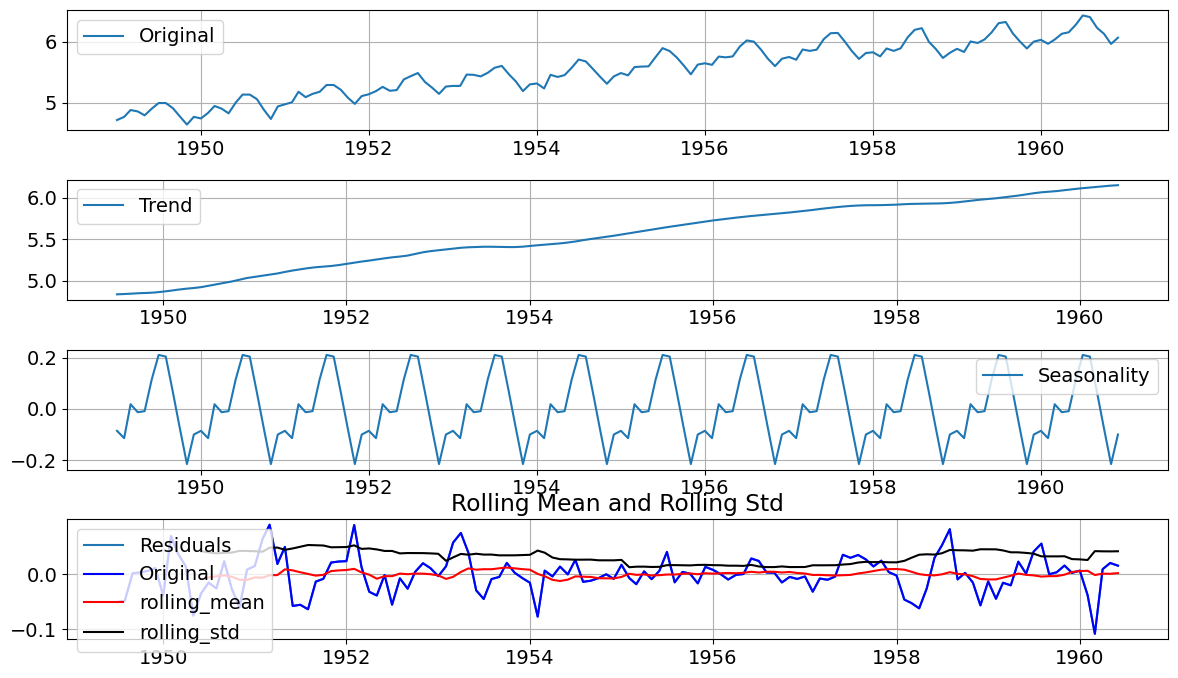

In [37]:
plt.figure(figsize=(12,7))

plt.subplot(411)
plt.plot(indexed_dataset_logscale, label = 'Original')
plt.legend(loc = 'best')

plt.subplot(412)
plt.plot(trend, label = 'Trend')
plt.legend(loc = 'best')

plt.subplot(413)
plt.plot(seasonal, label = 'Seasonality')
plt.legend(loc = 'best')

plt.subplot(414)
plt.plot(residual, label = 'Residuals')
plt.legend(loc = 'best')

plt.tight_layout()

decomposedLogData = residual
decomposedLogData.dropna(inplace=True)
test_stationarity(decomposedLogData)